In [37]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HousePricePrediction") \
    .getOrCreate()

In [38]:
import os
print(os.getcwd())

/home/asish-jose/AI-ML/Big-Data/Spark


In [39]:
HOUSING_DATA = '../data/cal_housing.data'

In [40]:
df = spark.read.csv(
    HOUSING_DATA,
    inferSchema=True
)

In [41]:
columns = [
    "long",
    "lat",
    "medage",
    "totrooms",
    "totbdrms",
    "pop",
    "hshlds",
    "medinc",
    "medhv"
]

df = df.toDF(*columns)

In [42]:
df.show(5)
df.printSchema()

+-------+-----+------+--------+--------+------+------+------+--------+
|   long|  lat|medage|totrooms|totbdrms|   pop|hshlds|medinc|   medhv|
+-------+-----+------+--------+--------+------+------+------+--------+
|-122.23|37.88|  41.0|   880.0|   129.0| 322.0| 126.0|8.3252|452600.0|
|-122.22|37.86|  21.0|  7099.0|  1106.0|2401.0|1138.0|8.3014|358500.0|
|-122.24|37.85|  52.0|  1467.0|   190.0| 496.0| 177.0|7.2574|352100.0|
|-122.25|37.85|  52.0|  1274.0|   235.0| 558.0| 219.0|5.6431|341300.0|
|-122.25|37.85|  52.0|  1627.0|   280.0| 565.0| 259.0|3.8462|342200.0|
+-------+-----+------+--------+--------+------+------+------+--------+
only showing top 5 rows

root
 |-- long: double (nullable = true)
 |-- lat: double (nullable = true)
 |-- medage: double (nullable = true)
 |-- totrooms: double (nullable = true)
 |-- totbdrms: double (nullable = true)
 |-- pop: double (nullable = true)
 |-- hshlds: double (nullable = true)
 |-- medinc: double (nullable = true)
 |-- medhv: double (nullable = 

## EDA

In [43]:
df.describe().select('summary','totrooms', 'pop', 'medage', 'medhv').show()

+-------+------------------+------------------+------------------+------------------+
|summary|          totrooms|               pop|            medage|             medhv|
+-------+------------------+------------------+------------------+------------------+
|  count|             20640|             20640|             20640|             20640|
|   mean|2635.7630813953488|1425.4767441860465|28.639486434108527|206855.81690891474|
| stddev|2181.6152515827944|  1132.46212176534| 12.58555761211163|115395.61587441359|
|    min|               2.0|               3.0|               1.0|           14999.0|
|    max|           39320.0|           35682.0|              52.0|          500001.0|
+-------+------------------+------------------+------------------+------------------+



In [44]:
df.select("pop", "totbdrms").show(10)

+------+--------+
|   pop|totbdrms|
+------+--------+
| 322.0|   129.0|
|2401.0|  1106.0|
| 496.0|   190.0|
| 558.0|   235.0|
| 565.0|   280.0|
| 413.0|   213.0|
|1094.0|   489.0|
|1157.0|   687.0|
|1206.0|   665.0|
|1551.0|   707.0|
+------+--------+
only showing top 10 rows



In [45]:
# Distribution of the median age of the people living in the area:

result_df = df.groupBy("medage") \
    .count().sort("medage", ascending=False)

result_df.show(10)

+------+-----+
|medage|count|
+------+-----+
|  52.0| 1273|
|  51.0|   48|
|  50.0|  136|
|  49.0|  134|
|  48.0|  177|
|  47.0|  198|
|  46.0|  245|
|  45.0|  294|
|  44.0|  356|
|  43.0|  353|
+------+-----+
only showing top 10 rows



<Axes: xlabel='medage'>

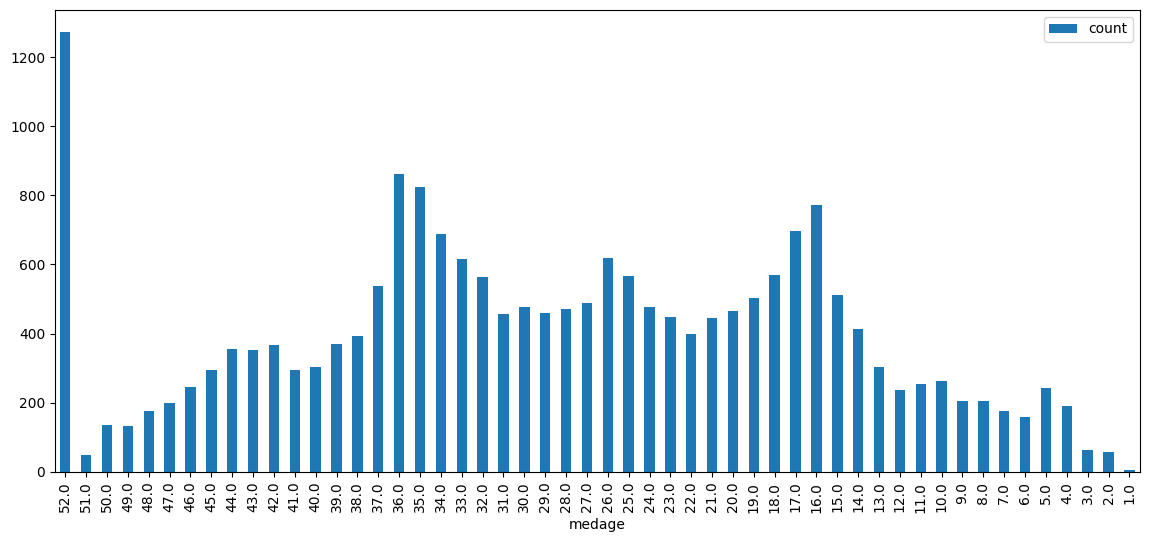

In [46]:
result_df.toPandas().plot.bar(x='medage',figsize=(14, 6))

Most of the residents are either in their youth or they settle here during their senior years. Some data are showing median age < 10 which seems to be out of place.

In [47]:
# Check for Missing Values

from pyspark.sql.functions import col, isnan, when, count

df.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c)
    for c in df.columns
]).show()

+----+---+------+--------+--------+---+------+------+-----+
|long|lat|medage|totrooms|totbdrms|pop|hshlds|medinc|medhv|
+----+---+------+--------+--------+---+------+------+-----+
|   0|  0|     0|       0|       0|  0|     0|     0|    0|
+----+---+------+--------+--------+---+------+------+-----+



In [48]:
df.columns

['long',
 'lat',
 'medage',
 'totrooms',
 'totbdrms',
 'pop',
 'hshlds',
 'medinc',
 'medhv']

In [49]:
# define feature columns

feature_columns = [
    'long',
    'lat',
    'medage',
    'totrooms',
    'totbdrms',
    'pop',
    'hshlds',
    'medinc'
]

### Vector Assembler

In [50]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

In [51]:
# transform dataset

final_df = assembler.transform(df)

final_df = final_df.select('features', 'medhv')
final_df.show(5)

+--------------------+--------+
|            features|   medhv|
+--------------------+--------+
|[-122.23,37.88,41...|452600.0|
|[-122.22,37.86,21...|358500.0|
|[-122.24,37.85,52...|352100.0|
|[-122.25,37.85,52...|341300.0|
|[-122.25,37.85,52...|342200.0|
+--------------------+--------+
only showing top 5 rows



In [52]:
final_df.columns

['features', 'medhv']

In [53]:
# scaling

from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(final_df)

scaled_df = scaler_model.transform(final_df)
scaled_df.select("features", "scaledFeatures", "medhv").show(5)

+--------------------+--------------------+--------+
|            features|      scaledFeatures|   medhv|
+--------------------+--------------------+--------+
|[-122.23,37.88,41...|[-1.3278030546902...|452600.0|
|[-122.22,37.86,21...|[-1.3228118684350...|358500.0|
|[-122.24,37.85,52...|[-1.3327942409452...|352100.0|
|[-122.25,37.85,52...|[-1.3377854272003...|341300.0|
|[-122.25,37.85,52...|[-1.3377854272003...|342200.0|
+--------------------+--------------------+--------+
only showing top 5 rows



In [54]:
# train test split

train_data , test_data = scaled_df.randomSplit([0.8, 0.2], seed=42)

### Linear Regression model 

In [55]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol = "scaledFeatures",
    labelCol = "medhv"
)

In [56]:
model = lr.fit(train_data)

26/05/13 12:25:05 WARN Instrumentation: [d7a7dabe] regParam is zero, which might cause numerical instability and overfitting.


In [57]:
predictions = model.transform(test_data)

In [58]:
predictions.select(
    "scaledFeatures",
    "medhv",
    "prediction"
).show(5)

+--------------------+--------+------------------+
|      scaledFeatures|   medhv|        prediction|
+--------------------+--------+------------------+
|[-2.3609786094955...|103600.0|101368.49876353651|
|[-2.3260403057099...|106700.0| 190006.4772243899|
|[-2.3260403057099...| 73200.0| 76395.60828417985|
|[-2.3060755606895...| 90100.0|161928.67226364548|
|[-2.3010843744344...| 67000.0|120168.19580396361|
+--------------------+--------+------------------+
only showing top 5 rows



### Model Evaluation

In [59]:
from pyspark.ml.evaluation import RegressionEvaluator

rmse_evaluator = RegressionEvaluator(
    labelCol="medhv",
    predictionCol="prediction",
    metricName="rmse"
)

rmse = rmse_evaluator.evaluate(predictions)
print("RMSE:", rmse)

RMSE: 71551.5488001882


In [60]:
r2_evaluator = RegressionEvaluator(
    labelCol="medhv",
    predictionCol="prediction",
    metricName="r2"
)

r2 = r2_evaluator.evaluate(predictions)

print("R2 Score:", r2)

R2 Score: 0.6299743383482933


In [61]:
mae_evaluator = RegressionEvaluator(
    labelCol="medhv",
    predictionCol="prediction",
    metricName="mae"
)

mae = mae_evaluator.evaluate(predictions)

print("MAE:", mae)

MAE: 51658.52290864318


### Pipeline

In [66]:
from pyspark.ml import Pipeline

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withStd=True,
    withMean=True
)
lr = LinearRegression(
    featuresCol="scaledFeatures",
    labelCol="medhv",
    predictionCol="predicted_price"

)

pipeline = Pipeline(stages=[assembler, scaler, lr])
train, test = df.randomSplit([0.8, 0.2], seed=42)

pipeline_model = pipeline.fit(train)
predictions = pipeline_model.transform(test)

predictions.select(
    "medhv",
    "predicted_price"
).show(5)

26/05/13 12:51:50 WARN Instrumentation: [f990287d] regParam is zero, which might cause numerical instability and overfitting.


+--------+------------------+
|   medhv|   predicted_price|
+--------+------------------+
|103600.0|101368.49876352947|
|106700.0|190006.47722438254|
| 73200.0| 76395.60828417259|
| 90100.0| 161928.6722636366|
| 67000.0|120168.19580395587|
+--------+------------------+
only showing top 5 rows

